<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/QUANTUMGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["TORCHINDUCTOR_FREEZE_PCH"] = "1"
# Also force Inductor to use a fresh directory if the previous one is locked
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_compile_fresh"

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [ ]:
#dedicated to the public domain for the glory of god.
#baruch adonai el shaddai
#Eloheinu shebashamayim yached shimcha v'kayeim malchutecha tamid umloch aleinu le'olam va'ed
#2026 joshuah.rainstar@gmail.com

#Version 2.1 EpistemicGPT
#current notes:
#your choice on whether to key the carving directions in the subspaceunembed to n_layer or a fixed budget\
#and whether to run them all in parallel or sequential
#your choice on lelu gelu or some other nonlinearity
#figure out some kind of ste alpha decay schedule or dont use


'''
Train all MLPS of form(linear,LELU,linear) with the following LR
width LR
4 2.0667168855e-01
8 1.0333584427e-01
16 5.1667922137e-02
32 2.5833961069e-02
64 1.2916980534e-02
128 6.4584902671e-03
192 4.3056601781e-03
256 3.2292451336e-03
384 2.1528300890e-03
512 1.6146225668e-03
1024 8.0731128339e-04
2048 4.0365564170e-04
4096 2.0182782085e-04
8192 1.0091391042e-04
16384 5.0456955212e-05
Generalization error bounds for two-layer
neural networks with Lipschitz loss function
Jiang Yu Nguwi∗ Nicolas Privault
 1) activation/module-scale Lipschitz factor for the RMSNorm-guarded MLP
       L_eff ~= 1.0998393201 * sqrt(dim)

    2) expected top Hessian eigenvalue for the simplified linear+squared-loss model
       with Gaussian batch inputs centered coordinatewise at 1.09984:
       lambda_max = sigma^2 + dim * (1.09984)^2

    3) hypothetical gradient-descent learning-rate edge and a conservative mean
       lr_edge = 2 / lambda_max
       lr = lr_edge / 2

further estimations, calculations suggest that the LR on attention should be the MLP but divided by the highest width of the internal representation.
in an OST model, its lr/3.

for embedding layer, LR is allowed to be quite large.
(1 / log(sqrt(max(dim, vocab))))*0.5

for unembedding(assume we will parallelize, not accumulate sequential):
lr_unembed = (1 / (sqrt(n_slices + 1) * log(max(dim, vocab))))*0.5

Scheduling should decay the entire model gradually to a lower bound.  that lowest possible bound that is useful to train is quite simply 1 / (1099.84 * sqrt(max(dim,vocab)).
training below this may not be effective or useful.

any change to nonlinearities, any scaling operations, any use of softmax objectively will change and invalidate this prospective learning rate schedule.


'''
import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F

def make_boundary_ste_hook(alpha=1.0):
    def hook(module, grad_input, grad_output):
        if not grad_input or not grad_output:
            return None

        gi = grad_input[0]
        go = grad_output[0]

        if gi is None or go is None:
            return None
        if gi.shape != go.shape:
            return None

        new_gi = alpha * go + (1.0 - alpha) * gi
        return (new_gi,) + tuple(grad_input[1:])
    return hook

def make_texture_hook(ema_decay=0.95, roughness_decay=0.95,
                      smooth_floor=0.3, rough_focus=0.8, eps=1e-8):
    """
    External memory per linear layer, living in the closure.

    State:
      direction: EMA of gradient (unnormalized accumulator, normalized on use)
      variance:  EMA of squared deviation from direction (roughness)
      grad_sq:   EMA of squared gradient norm (for normalizing variance)
      scale:     the integrated scalar output
    """
    state = {
        "direction": None,   # running mean gradient, same shape as grad
        "variance": None,    # running mean squared deviation from direction
        "grad_sq_ema": None, # running mean of ||g||^2 for relative roughness
        "step": 0,
    }

    def hook(module, grad_input, grad_output):
        g = grad_input[0]
        if g is None:
            return None

        with torch.no_grad():
            flat = g.reshape(g.shape[0], -1)  # (batch, features) or just (features,)

            # initialize state on first call
            if state["direction"] is None:
                state["direction"] = torch.zeros_like(flat)
                state["variance"] = torch.zeros(flat.shape[0], device=flat.device)
                state["grad_sq_ema"] = torch.zeros(flat.shape[0], device=flat.device)

            state["step"] += 1
            a = ema_decay
            ar = roughness_decay

            # bias correction weight
            bc = 1.0 / (1.0 - a ** state["step"])

            # update direction EMA
            state["direction"].mul_(a).add_(flat, alpha=1 - a)
            dir_corrected = state["direction"] * bc

            # normalize direction to unit vector per sample
            dir_norm = dir_corrected.norm(dim=-1, keepdim=True).clamp(min=eps)
            d_hat = dir_corrected / dir_norm

            # deviation: how far is current gradient from principal direction?
            proj_scalar = (flat * d_hat).sum(dim=-1, keepdim=True)
            orthogonal = flat - proj_scalar * d_hat
            dev_sq = (orthogonal ** 2).sum(dim=-1)
            grad_sq = (flat ** 2).sum(dim=-1)

            # update roughness and magnitude EMAs
            state["variance"].mul_(ar).add_(dev_sq, alpha=1 - ar)
            state["grad_sq_ema"].mul_(ar).add_(grad_sq, alpha=1 - ar)

            # relative roughness: what fraction of gradient energy is off-direction?
            # 0 = perfectly aligned with principal direction (smooth)
            # 1 = entirely orthogonal (rough)
            roughness = state["variance"] / state["grad_sq_ema"].clamp(min=eps)
            roughness = roughness.clamp(0, 1)

            # --- scaling logic ---
            # smoothness = 1 - roughness
            # when smooth: scale down overall (don't overcorrect)
            # when rough: focus on direction, amplify along it

            smoothness = 1.0 - roughness  # per-sample

            # overall magnitude scale: high when rough, drops to floor when smooth
            magnitude = smooth_floor + (1.0 - smooth_floor) * roughness
            magnitude = magnitude.unsqueeze(-1)

            # focus: how much to concentrate onto principal direction
            # rough -> high focus, smooth -> low focus (let full gradient through at reduced scale)
            focus = rough_focus * roughness.unsqueeze(-1)

            # decompose gradient
            g_parallel = proj_scalar * d_hat
            g_ortho = orthogonal

            # blend: ortho component gets attenuated by focus
            g_new = magnitude * (g_parallel + (1.0 - focus) * g_ortho)

        # reshape back and return
        out = list(grad_input)
        out[0] = g_new.reshape(g.shape)
        return tuple(out)

    return hook, state

class LELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = math.pi / math.sqrt(3.0) #logistic CDF matched scale beats gelu and is less expensive

    def forward(self, x):
        return x * torch.sigmoid(self.scale * x)



class RoPE(nn.Module):
    def __init__(self, dim, max_len=4096):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        w_max = torch.pi / 2 #highest frequency- one rotation in 4 tokens
        w_min = torch.pi / (max_len) #this sets the lowest scale to that sufficient to resolve needle at depth.
        #most effectively, set your context size to more than you ever intend to handle
        B = 10
        setfreqs_hi = torch.logspace(
                    start=math.log(w_min,B),
                    end=math.log(w_max,B),
                    steps=(dim // 4),
                    base=B
                )


        setfreqs_lo = w_max - torch.logspace(
            start=math.log(w_min,B),
            end=math.log(w_max,B),
            steps=(dim // 4) + 1,
            base=B
        )[:-1] # Drop last to match size and allow a smooth continuation

                # Combine
        setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))
        inv_freq, _ = torch.sort(setfreqs,descending=True) #this give us a sigmoidal distribution of frequencies.
        #many large, many small, few near the midpoint.

        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        self.register_buffer('cos_cached', freqs.cos())
        self.register_buffer('sin_cached', freqs.sin())

    def get_embeddings(self, positions, device):
        positions = positions.clamp(0, self.max_len - 1).long()
        cos = F.embedding(positions, self.cos_cached).unsqueeze(0).unsqueeze(0) # [1, 1, T, D]
        sin = F.embedding(positions, self.sin_cached).unsqueeze(0).unsqueeze(0)
        return cos, sin

    def forward(self, x, positions=None):
        # x: (B, H, T, D) where D = self.dim (head_dim)
        if positions is None:
            T = x.shape[-2]
            positions = torch.arange(T, device=x.device)

        cos, sin = self.get_embeddings(positions, x.device)
        # cos, sin: [1, 1, T, D//2]

        D = x.shape[-1]
        mid = D // 2
        h1 = x[..., :mid]   # first half of dimensions
        h2 = x[..., mid:]   # second half of dimensions

        # Adjacent pairing within each half:
        # h1 pairs: (h1[0],h1[1]), (h1[2],h1[3]), ...
        # h2 pairs: (h2[0],h2[1]), (h2[2],h2[3]), ...
        #
        # h1 gets sign-flipped convention (sin term adds instead of subtracts)
        # h2 gets standard convention
        #
        # This is achieved by negating the "b" element of each pair in h1
        # before feeding into the standard rotation formula.

        # For h1: negate odd-indexed elements, apply rotation, un-negate
        # Equivalent to: the kernel contribution for h1 pairs becomes
        #   S * cos(w*d) + A * sin(w*d)
        # instead of
        #   S * cos(w*d) - A * sin(w*d)

        # Extract paired elements for h1
        h1_a = h1[..., 0::2]   # even indices (the "real" part)
        h1_b = h1[..., 1::2]   # odd indices (the "imaginary" part)

        # Extract paired elements for h2
        h2_a = h2[..., 0::2]
        h2_b = h2[..., 1::2]

        # Split cos/sin for the two halves' frequency ranges
        # First D//4 frequencies go to h1, last D//4 to h2
        n_pairs_per_half = mid // 2  # D//4
        cos1 = cos[..., :n_pairs_per_half]
        sin1 = sin[..., :n_pairs_per_half]
        cos2 = cos[..., n_pairs_per_half:]
        sin2 = sin[..., n_pairs_per_half:]

        # H1: flipped convention (negate b before rotation)
        # Standard rotation on (a, -b):
        #   out_a = a * cos - (-b) * sin = a * cos + b * sin
        #   out_b_neg = a * sin + (-b) * cos = a * sin - b * cos
        # Then un-negate b: out_b = -(a * sin - b * cos) = -a * sin + b * cos
        out_h1_a = h1_a * cos1 + h1_b * sin1
        out_h1_b = -h1_a * sin1 + h1_b * cos1

        # H2: standard convention
        #   out_a = a * cos - b * sin
        #   out_b = a * sin + b * cos
        out_h2_a = h2_a * cos2 - h2_b * sin2
        out_h2_b = h2_a * sin2 + h2_b * cos2

        # Reassemble: interleave a,b back into adjacent pairs
        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)



class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.act = LELU()
        self.c_fc  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        self.c_proj  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_wide(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.act = LELU()
        self.c_fc  = nn.Linear(config.n_embd, config.n_embd*2, bias=config.bias)

        self.c_proj  = nn.Linear(config.n_embd*2, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_bottle(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd,  config.n_embd//2, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd//2, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x



class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.depth = 0
        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        dim = config.n_embd
        self.head_dim = dim // self.n_heads


        self.q_proj = nn.Linear(dim,dim,bias=False)
        self.k_proj = nn.Linear(dim,dim,bias=False)
        self.v_proj =nn.Linear(dim,dim,bias=False)
        self.o_proj =nn.Linear(dim,dim,bias=False)
        self.v_sink_basis = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))
        self.sink_key = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))

        self.mask = None #set in GPT main at model time to ensure its on GPU
        self.rope = config.rope
        self.alpha = 2.0 * math.log(2.0)

    def erode(self, B, H, T, device):
        alpha = 0.3
        sigma_frac = 0.18

        pos = torch.arange(T, device=device).float()              # [T]

        # spread head preferences across sequence: early -> middle -> late
        head_centers = torch.linspace(0, T - 1, H, device=device) # [H]

        # distance of each source position from each head's preferred region
        src_dist = pos.view(1, 1, T) - head_centers.view(H, 1, 1) # [H,1,T]
        src_dist = src_dist.expand(H, T, T).abs()                 # [H,T,T]

        sigma = max(T * sigma_frac, 1.0)

        # highest drop away from preferred region, lowest drop near it
        drop_probs = alpha * (1.0 - torch.exp(-(src_dist ** 2) / (2 * sigma ** 2)))

        # keep causal structure
        causal = torch.tril(torch.ones(T, T, device=device))
        drop_probs = drop_probs * causal.unsqueeze(0)
        keep_probs = 1.0 - drop_probs

        keep_mask = torch.bernoulli(
            keep_probs.unsqueeze(0).expand(B, H, T, T)
        )
        return keep_mask

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim


        k = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)

        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        q = F.rms_norm(q, (D,),eps=1e-6) #never ever norm k, you stupid fuck

        q = self.rope(q)
        k = self.rope(k)
        k2 = torch.cat([k, self.sink_key.expand(B, -1, -1, -1)], dim=2)

        scores = (q @ k2.transpose(-2, -1)) * (math.log(T+1) * math.log(D))
        # Soft Attention

        mask = self.mask[:, :, :T, :T]
        null_col = torch.ones(1, 1, T, 1, device=x.device)
        mask_use = torch.cat([mask, null_col], dim=-1)
        soft_scores = F.softplus(self.alpha* scores)
        # STE: Forward sets small/neg values to 0, Backward ignores the zeroing
        # Values < 1e-6 do not participate in mass/scaling but receive gradients
        threshold = 1e-6
        pruned_scores = torch.where(soft_scores < threshold, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned_scores - soft_scores).detach()
        soft_scores = soft_scores.masked_fill(mask_use == 0, 0.0) #prevent cheating here

        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)
        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)
        attn_real = attn[:, :, :, :T]   # drop the null column
        y_context = attn_real @ v

        vn = F.normalize(v, dim=-1)
        y_context = y_context - (y_context * vn).sum(dim=-1, keepdim=True) * vn
        y = F.rms_norm(y_context, (D,)) + self.v_sink_basis
        y_flat = y.transpose(1, 2).contiguous().view(B, T, -1)

        attn_flat = attn[:, :, :, :T].mean(dim=1)  # (B, T, T)
        mixture = attn_flat @ x

        xn = F.normalize(x, dim=-1)  # (B, T, C)
        mix2 = attn_flat @ xn

        weighted_src = F.normalize(mix2, dim=-1)
        mutual = mixture - (mixture * weighted_src).sum(dim=-1, keepdim=True) * weighted_src

        truth = self.o_proj(y_flat)


        if self.training:
            mod_mask = self.erode(B,H,T,x.device)
            mask =  mask.masked_fill(mod_mask == 0, 0.0)
            eroded_attn  = attn_real.masked_fill(mask == 0, 0.0)

            y_context =eroded_attn @ v
            y_context = y_context - (y_context * vn).sum(dim=-1, keepdim=True) * vn
            y = F.rms_norm(y_context, (D,)) + self.v_sink_basis
            y_flat = y.transpose(1, 2).contiguous().view(B, T, -1)

            tangent= self.o_proj(y_flat)
            truth = tangent + (truth - tangent).detach()


        return truth# + mutual

def norm(x):
    return F.rms_norm(x, (x.size(-1),),eps=1e-6)

class Block(nn.Module):
    def __init__(self, config, block_idx):
        super().__init__()
        self.attn = Attention(config)
        self.attn_dir = MLP_bottle(config)
        self.ffn = MLP(config)
        self.config = config

    def forward(self, x):
        a = norm(x)
        z = self.attn(a)
        vn = F.normalize(self.attn_dir(a), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = q + z
        x = x + self.ffn(norm(x))

        return x



@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 66 #shakespeare
    n_layer: int = 1
    n_head: int = 6

    n_embd: int = 192 #recommend 32 min per head
    dropout: float = 0.0
    bias: bool = False
    rope: nn.Module = None
    bottle: nn.Module = None
    device: str = "cuda"

class SoftplusCELoss(nn.Module):
    def __init__(self, ignore_index=-1, label_smoothing=0.0):
        super().__init__()
        self.ignore_index = ignore_index
        self.label_smoothing = label_smoothing
        self.alpha = 2.0 * math.log(2.0) #emulates softmax

    def forward(self, logits, targets):
        # logits: (B, V) or (B, T, V)
        # targets: (B,) or (B, T)
        flat_logits = logits.view(-1, logits.size(-1))
        flat_targets = targets.view(-1)

        mask = flat_targets != self.ignore_index
        flat_logits = flat_logits[mask]
        flat_targets = flat_targets[mask]

        if flat_targets.numel() == 0:
            return flat_logits.sum() * 0.0

        sp = F.softplus(self.alpha* flat_logits)

        threshold = 1e-6
        pruned = torch.where(sp < threshold, torch.zeros_like(sp), sp)
        sp = sp + (pruned - sp).detach()  # STE

        sp_sum = sp.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
        probs = sp * scale  # sub-unity simplex

        # gather target probs
        target_probs = probs.gather(1, flat_targets.unsqueeze(1)).squeeze(1)

        # NLL on the softplus-normalized probs
        loss = -torch.log(target_probs + 1e-6)

        if self.label_smoothing > 0.0:
            # smooth term: average negative log-prob across vocab
            smooth_loss = -torch.log(probs + 1e-6).mean(dim=-1)
            loss = (1.0 - self.label_smoothing) * loss + self.label_smoothing * smooth_loss

        return loss.mean()




class ParallelSubspaceUnembed(nn.Module):
    """
    Parallel carveouts against the same h.
    Diversity is enforced only through cosine-distinct subspaces.
    Each slice owns:
      - a direction net that proposes a subspace direction
      - a vocab projection for the carved component
    Vocab dropout: during training, each proj randomly masks a fraction of
    vocab entries, with the constraint that every vocab entry is covered by
    at least one slice. This prevents attention from relying on any specific
    unembedding pathway and forces compositional work back into attention.
    Output:
      logits: summed vocab logits from all slices (+ residual head if enabled)
      sep_loss: pairwise squared cosine overlap penalty between slice directions
    """

    def __init__(
        self,
        d_model,
        vocab_size,
        n_slices=4,
        use_residual_head=True,
        vocab_dropout=0.25,
        eps=1e-6,
    ):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.n_slices = n_slices
        self.use_residual_head = use_residual_head
        self.vocab_dropout = vocab_dropout
        self.eps = eps

        self.dir_nets = nn.ModuleList([
            nn.Linear(d_model, d_model, bias=False)
            for _ in range(n_slices)
        ])
        self.projs = nn.ModuleList([
            nn.Linear(d_model, vocab_size, bias=False)
            for _ in range(n_slices)
        ])

        if use_residual_head:
            self.residual_proj = nn.Linear(d_model, vocab_size, bias=False)
        else:
            self.residual_proj = None

    def _sample_vocab_masks(self, device):
        """
        For each slice, independently drop vocab_dropout fraction of vocab entries.
        Then fix up: any vocab entry that got dropped from ALL slices gets
        restored in one randomly chosen slice.

        Returns: list of n_slices boolean tensors, each [vocab_size],
                 True = keep, False = dropped.
        """
        # each slice independently keeps (1 - vocab_dropout) fraction
        masks = [
            torch.rand(self.vocab_size, device=device) > self.vocab_dropout
            for _ in range(self.n_slices)
        ]

        # stack to [n_slices, vocab_size] for coverage check
        stacked = torch.stack(masks, dim=0)  # [n_slices, V]
        uncovered = ~stacked.any(dim=0)      # [V] -- True where ALL slices dropped

        if uncovered.any():
            # for each uncovered vocab entry, randomly assign to one slice
            uncovered_idx = uncovered.nonzero(as_tuple=True)[0]
            assignments = torch.randint(
                0, self.n_slices, (uncovered_idx.shape[0],), device=device
            )
            for s in range(self.n_slices):
                restore = uncovered_idx[assignments == s]
                if restore.numel() > 0:
                    masks[s][restore] = True

        return masks

    def forward(self, h):
        # h: [B, T, D]
        B, T, D = h.shape
        assert D == self.d_model

        logits = h.new_zeros(B, T, self.vocab_size)
        dirs = []
        components = []

        # sample vocab masks once per forward pass
        if self.training and self.vocab_dropout > 0:
            vocab_masks = self._sample_vocab_masks(h.device)
        else:
            vocab_masks = None

        for i in range(self.n_slices):
            v = self.dir_nets[i](h)                            # [B,T,D]
            v = F.normalize(v, dim=-1, eps=self.eps)           # unit direction
            c = (h * v).sum(dim=-1, keepdim=True) * v          # projection of h onto v

            dirs.append(v)
            components.append(c)

            slice_logits = self.projs[i](c)                    # [B,T,V]

            if vocab_masks is not None:
                # mask is [V], broadcast to [1,1,V]
                # scale kept logits to compensate for missing slices
                mask = vocab_masks[i].unsqueeze(0).unsqueeze(0).float()
                slice_logits = slice_logits * mask / (1.0 - self.vocab_dropout + self.eps)

            logits = logits + slice_logits

        if self.use_residual_head:
            used = torch.stack(components, dim=0).sum(dim=0)   # [B,T,D]
            residual = h - used
            logits = logits + self.residual_proj(residual)

        # pairwise squared cosine overlap penalty
        sep_loss = h.new_zeros(())
        if self.training:
            count = 0
            for i in range(self.n_slices):
                for j in range(i + 1, self.n_slices):
                    cos_ij = (dirs[i] * dirs[j]).sum(dim=-1)   # [B,T]
                    sep_loss = sep_loss + (cos_ij ** 2).mean()
                    count += 1
            if count > 0:
                sep_loss = sep_loss / count

        if self.training:
            return logits, sep_loss
        else:
            return logits


"""
Context Cone Target Warping

The target embedding for a token lives at a centroid on the hypersphere.
As context accumulates, three continuous vectors push the target away
from the centroid along a context-specific ray:

  1. ContentBag  - V-dimensional count histogram (what and how much)
  2. EdgeBag     - V^2 sparse count (which transitions and how often)
  3. PathAccum   - continuous random-projection accumulators per n-gram level

The walk distance from the centroid grows with context length,
reflecting increasing certainty about what this specific token
means in this specific context.

Usage in training loop:
    cone = ContextCone(vocab_size=256, embed_dim=192)

    # token_ids: (B, T) input sequence
    # target_embeds: (B, T, D) embeddings of next-token targets
    fingerprints, magnitudes = cone.encode(token_ids)
    warped_targets = cone.warp(fingerprints, magnitudes, target_embeds)

    # use warped_targets in place of raw target embeds for loss
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class ContextCone(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        path_dim: int = 64,
        path_levels: int = 5,
        max_warp: float = 0.3,
        seed: int = 42,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.path_dim = path_dim
        self.path_levels = path_levels
        self.max_warp = max_warp

        # content fingerprint is V-dimensional counts
        # edge fingerprint is stored sparse, projected down
        self.edge_proj_dim = min(vocab_size, 128)

        # random projection for edges: (V, V) -> edge_proj_dim
        # deterministic from seed, not learned
        rng = torch.Generator().manual_seed(seed)
        # for each (prev, cur) pair, a random direction in R^edge_proj_dim
        # stored as two factor matrices for efficiency: edge_vec = A[prev] + B[cur]
        # their outer interaction via the accumulation gives us edge sensitivity
        self.register_buffer(
            'edge_A',
            torch.randn(vocab_size, self.edge_proj_dim, generator=rng) / math.sqrt(self.edge_proj_dim)
        )
        self.register_buffer(
            'edge_B',
            torch.randn(vocab_size, self.edge_proj_dim, generator=rng) / math.sqrt(self.edge_proj_dim)
        )

        # random direction vectors for path n-gram accumulation
        # for each n-gram level, each token contributes a random direction
        # the n-gram direction is the sum of position-modulated token directions
        self.register_buffer(
            'path_dirs',
            torch.randn(path_levels, vocab_size, path_dim, generator=rng) / math.sqrt(path_dim)
        )
        # position-dependent mixing scalars for path (breaks commutativity)
        # use golden-ratio-based phases so positions never repeat exactly
        phases = torch.zeros(path_levels, 1024)  # up to 1024 positions
        for lv in range(path_levels):
            for p in range(1024):
                # irrational rotation per level
                phases[lv, p] = math.cos((p + 1) * (lv + 1) * 2.3999632297286533)
        self.register_buffer('pos_phases', phases)

        # total fingerprint width
        self.fp_width = vocab_size + self.edge_proj_dim + path_dim * path_levels

        # projection from fingerprint space to embedding space
        # this IS learned, but initialized small
        rng_proj = torch.Generator().manual_seed(seed + 999)
        proj_matrix = torch.randn(self.fp_width, embed_dim, generator=rng_proj)
        proj_matrix = proj_matrix / math.sqrt(self.fp_width)
        self.register_buffer('direction_proj', proj_matrix)

    @torch.compiler.disable
    def encode(self, token_ids):
        """
        Compute context fingerprints and warp magnitudes for each position.

        token_ids: (B, T) integer token ids

        Returns:
            fingerprints: (B, T, fp_width) continuous context vectors
            magnitudes: (B, T) warp magnitude at each position (grows with t)
        """
        B, T = token_ids.shape
        device = token_ids.device

        # === Content bag: cumulative histogram ===
        # one-hot accumulation
        onehot = F.one_hot(token_ids.long(), self.vocab_size).float()  # (B, T, V)
        content = onehot.cumsum(dim=1)  # (B, T, V) running counts

        # === Edge bag: cumulative transition counts, projected ===
        # for each position t > 0, the edge (token[t-1], token[t]) fires
        edges = torch.zeros(B, T, self.edge_proj_dim, device=device)
        if T > 1:
            prev_tok = token_ids[:, :-1].long()  # (B, T-1)
            cur_tok = token_ids[:, 1:].long()     # (B, T-1)
            # edge direction for each transition
            edge_vecs = self.edge_A[prev_tok] * self.edge_B[cur_tok]  # (B, T-1, edge_proj_dim)
            # cumulative sum, shifted right by 1 (position 0 has no edges)
            edge_cumsum = edge_vecs.cumsum(dim=1)  # (B, T-1, edge_proj_dim)
            edges[:, 1:] = edge_cumsum

        # === Path accumulators: continuous n-gram random projections ===
        path_parts = []
        for lv in range(self.path_levels):
            n = lv + 1  # n-gram order
            accum = torch.zeros(B, T, self.path_dim, device=device)

            if T >= n:
                # for each position t, the n-gram is tokens[t-n+1:t+1]
                # its direction is sum of path_dirs[lv][tok[i]] * pos_phase[lv][i_within_ngram]
                # we compute this incrementally

                # build the n-gram contribution at each valid position
                for offset in range(n):
                    # which token is at position (offset within the n-gram)
                    # for position t, this is token_ids[:, t - n + 1 + offset]
                    start_idx = offset
                    end_idx = T - n + 1 + offset
                    if end_idx <= start_idx:
                        continue
                    toks = token_ids[:, start_idx:end_idx].long()  # (B, T-n+1)
                    dirs = self.path_dirs[lv][toks]  # (B, T-n+1, path_dim)

                    # position-dependent phase within the n-gram
                    phase = self.pos_phases[lv, offset]
                    dirs = dirs * phase

                    # place into the right output positions (n-1 onwards)
                    accum[:, (n-1):T, :] += dirs[:, :(T-n+1), :]

                # cumulative sum: accumulate all n-grams up to this position
                accum = accum.cumsum(dim=1)

            path_parts.append(accum)

        # concatenate all path levels
        path = torch.cat(path_parts, dim=-1)  # (B, T, path_dim * path_levels)

        # === Assemble fingerprint ===
        fingerprints = torch.cat([content, edges, path], dim=-1)  # (B, T, fp_width)


        return fingerprints

    def warp(self, fingerprints):
        """
        Warp target embeddings along context-dependent rays.

        fingerprints: (B, T, fp_width)
        magnitudes: (B, T) how far to walk from centroid
        target_embeds: (B, T, D) original target token embeddings

        Returns:
            warped: (B, T, D) context-warped target embeddings
        """
        # project fingerprint to a direction in embedding space
        raw_direction = fingerprints @ self.direction_proj

        return raw_direction

    def forward(self, token_ids):
        """
        Convenience: encode and warp in one call.

        token_ids: (B, T) context token ids
        target_embeds: (B, T, D) target embeddings to warp

        Returns:
            warped: (B, T, D) context-warped targets
        """
        fingerprints = self.encode(token_ids)
        return self.warp(fingerprints)


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.rope = RoPE(config.n_embd // config.n_head, max_len=config.block_size)
        self.config.rope = self.rope

        self.transformer = nn.ModuleDict(dict(
        wte=ContextCone(config.vocab_size,config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(self.config,i) for i in range(config.n_layer)]),
        ))
        mask_tensor = torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size).to(device=self.config.device)
        self.register_buffer("mask", mask_tensor)
        i = 0
        for block in self.transformer.h:
          block.attn.mask = self.mask #set here
          block.attn.depth= i
          i = i + 1

        self._boundary_handles = []
        self._linear_states = {}
        #self.register_confined_backward() experiment with at LATER TIME
        self.criterion = SoftplusCELoss(ignore_index=-1)
        self.lm_head = ParallelSubspaceUnembed(config.n_embd, config.vocab_size)
        self.warp = ContextCone(config.vocab_size,config.n_embd)
        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))




    def register_confined_backward(self):
        states = {}
        handles = []
        mlphook = make_boundary_ste_hook(0.5)

        i = 1
        L = len(self.transformer.h)
        for block in self.transformer.h:
            handles.append(block.attn.register_full_backward_hook(make_boundary_ste_hook(float(1-2**(-i/L))))) #gently diminish contributions
            handles.append(block.attn_dir.register_full_backward_hook(mlphook)) #mlp contribution is tiny anyway
            i = i  + 1

        for name, m in self.named_modules():
            if isinstance(m, nn.Linear):
                hook, st = make_texture_hook()
                h = m.register_full_backward_hook(hook)
                handles.append(h)
                states[name] = st


        self._boundary_handles = handles
        self._linear_states=states



    def get_num_params(self):
        n_params = sum(p.numel() for p in self.parameters())
        return n_params
    def forward(self, idx, targets=None):
        b, T = idx.size()
        x = self.transformer.wte(idx)
        for i, block in enumerate(self.transformer.h):
            x= block(x)

        x = norm(x)


        if targets is not None:

          logits, aux_loss = self.lm_head(x)
          loss = self.criterion(logits, targets) +  aux_loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None
        return logits, loss

In [ ]:


import requests, os

base_url = "https://huggingface.co/datasets/cambridge-climb/BabyLM/resolve/main/clean/10M/"
target_dir = "./babylm_10m_cleaned"
os.makedirs(target_dir, exist_ok=True)

file_names = [
    "aochildes.txt",
    "cbt.txt",
    "children_stories.txt",
    "gutenberg.txt",
    "qed.txt",
    "simple_wikipedia.txt",
    "switchboard.txt",
    "wikipedia.txt"
]

# Optional addition: Shakespeare from another dataset
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt"
shakespeare_fname = "shakespeare.txt"

# Combined download logic
all_files = [(base_url + fname, fname) for fname in file_names]
all_files.append((shakespeare_url, shakespeare_fname))  # Add Shakespeare


# Download loop
for url, fname in all_files:
    out_path = os.path.join(target_dir, fname)
    print(f"📥 Downloading {fname}...")
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(resp.text)
    else:
        print(f"❌ Failed to download {fname} ({resp.status_code})")

print(f"✅ Done. Files saved to {target_dir}")

📥 Downloading aochildes.txt...
📥 Downloading cbt.txt...
📥 Downloading children_stories.txt...
📥 Downloading gutenberg.txt...
📥 Downloading qed.txt...
📥 Downloading simple_wikipedia.txt...
📥 Downloading switchboard.txt...
📥 Downloading wikipedia.txt...
📥 Downloading shakespeare.txt...
✅ Done. Files saved to ./babylm_10m_cleaned


In [ ]:
import os
import pickle
import numpy as np

# === Paths ===
source_dir = "./babylm_10m_cleaned"
out_dir    = "./babylm_char_tokenized"
os.makedirs(out_dir, exist_ok=True)

file_names = [
    "shakespeare.txt"#,"aochildes.txt", "cbt.txt", "children_stories.txt", "gutenberg.txt",
    #"qed.txt", "simple_wikipedia.txt", "switchboard.txt", "wikipedia.txt"
]

# === Load and split ===
train_texts, val_texts = [], []
char_set = set()

for fname in file_names:
    with open(os.path.join(source_dir, fname), encoding="utf-8") as f:
        lines = f.readlines()
        n = len(lines)
        split = int(0.9 * n)
        train_part = "".join(lines[:split])
        val_part   = "".join(lines[split:])
        train_texts.append(train_part)
        val_texts.append(val_part)
        char_set.update(train_part)
        char_set.update(val_part)

full_train = "\n".join(train_texts)
full_val   = "\n".join(val_texts)

# === Final vocab ===
char_set = sorted(set(char_set))
vocab_chars = ["<unk>"] + [c for c in char_set if c != "<unk>"]

stoi = {ch: i for i, ch in enumerate(vocab_chars)}
itos = {i: ch for ch, i in stoi.items()}

# === Encode function ===
def encode(text):
    return [stoi.get(c, 0) for c in text]

train_ids = np.array(encode(full_train), dtype=np.uint16)
val_ids   = np.array(encode(full_val),   dtype=np.uint16)

# === Save ===
train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({
        "vocab_size": len(stoi),
        "stoi": stoi,
        "itos": itos
    }, f)

print(f"✅ Char tokenizer finalized.")
print(f"🧾 Train tokens: {len(train_ids)} | Val tokens: {len(val_ids)}")
print(f"🔤 Vocab size: {len(stoi)}")

✅ Char tokenizer finalized.
🧾 Train tokens: 1016242 | Val tokens: 99152
🔤 Vocab size: 66


In [ ]:
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 8

# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap edata (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device, jitter=63, p_aligned=0.5, pad_len=0):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.pad_len = int(pad_len)
        self.sample_len = self.block_size + self.pad_len  # X length
        self.total = len(self.data) - self.sample_len - 1
        self.n_blocks = self.total // self.sample_len
        self.jitter = int(jitter)          # small random offset added to aligned start
        self.p_aligned = float(p_aligned)  # mix aligned and jittered

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.sample_len), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)

        for i in range(self.batch_size):
            # === THE FIX ===
            # Pick a TRULY random start index anywhere in the file
            # No grid, no alignment, no "base_block"
            start = np.random.randint(0, self.total)

            X[i] = self.data[start : start + self.sample_len]
            Y[i] = self.data[start + 1 + self.pad_len : start + 1 + self.pad_len + self.block_size]

        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )

#device="cpu"

config = GPTConfig(
    vocab_size=len(stoi),
    n_layer=8,
    n_embd=192,
    n_head=6,
    block_size=block_size,
    device = device
)
torch._dynamo.config.automatic_dynamic_shapes = True
train_dataset = GPUBatchDataset(train_ids, block_size, batch_size, device, pad_len=0)
# === DataLoader ===
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
model = GPT(config)
torch.compiler.reset()
model = torch.compile(model)
model = model.to(device)


number of parameters: 2.31M


In [ ]:
state_dict = torch.load("overfitshakespeare_tiny.pt")
model.load_state_dict(state_dict, strict=True) # strict=True confirms the match is perfect
print("Weights loaded successfully.")

Weights loaded successfully.


In [ ]:
#save the model
torch.save(model.state_dict(), "overfitshakespeare_tiny.pt")
print("Model weights saved successfully.")

Model weights saved successfully.


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
def train_epoch():
    model.train()
    itera = 0
    total_loss = 0
    for xb, yb in train_loader:
          xb, yb = xb[0], yb[0]  # unwrap batch dimension
          optimizer.zero_grad()
          logits, loss_true = model(xb, yb)
          loss = loss_true
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          total_loss += loss_true.item()
          losses.append(loss_true.item())
          print(itera, loss_true.item())
          itera = itera + 1
    return total_loss / len(train_loader)

# === Run Training ===
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 4.271859645843506
1 3.8707733154296875
2 3.5893301963806152
3 3.509467601776123
4 3.39833664894104
5 3.3844797611236572
6 3.269655704498291
7 3.2741329669952393
8 3.21738600730896
9 3.1503093242645264
10 3.1973071098327637
11 3.1271471977233887
12 3.1610772609710693
13 3.074723482131958
14 3.0347282886505127
15 3.0179383754730225
16 2.983776807785034
17 2.962920904159546
18 2.9220426082611084
19 2.9074819087982178
20 2.906639337539673
21 2.8787038326263428
22 2.8583028316497803
23 2.798382043838501
24 2.82770037651062
25 2.7893030643463135
26 2.743072748184204
27 2.7538578510284424
28 2.7406508922576904
29 2.7158608436584473
30 2.6825149059295654
31 2.657357931137085
32 2.676332473754883
33 2.6349709033966064
34 2.628906726837158
35 2.593837261199951
36 2.6799979209899902
37 2.618976354598999
38 2.5999374389648438
39 2.5761866569519043
40 2.5643560886383057
41 2.5781452655792236
42 2.5146641731262207
43 2.5482089519500732
44 2.5182995796203613
45 2.541532039642334
46 2.51518464088439

KeyboardInterrupt: 

In [ ]:
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.1857445240020752
1 1.2169444561004639
2 1.1549522876739502
3 1.1600022315979004
4 1.186947226524353
5 1.1727509498596191
6 1.239227056503296
7 1.2518854141235352
8 1.184149146080017
9 1.2036269903182983
10 1.202261209487915
11 1.2015944719314575
12 1.2107514142990112
13 1.1502455472946167
14 1.178167700767517
15 1.2340415716171265
16 1.1520966291427612
17 1.133914828300476
18 1.1826937198638916
19 1.1722005605697632
20 1.1928502321243286
21 1.087912917137146
22 1.184670329093933
23 1.110573410987854
24 1.2290337085723877
25 1.1390637159347534
26 1.1246252059936523
27 1.1323519945144653
28 1.1429498195648193
29 1.1245532035827637
30 1.1495165824890137
31 1.2053412199020386
32 1.2410752773284912
33 1.119628667831421
34 1.2015658617019653
35 1.151287317276001
36 1.126427412033081
37 1.2570748329162598
38 1.169486165046692
39 1.1996062994003296
40 1.1902331113815308
41 1.209773302078247
42 1.2159072160720825
43 1.1954106092453003
44 1.1277520656585693
45 1.202917218208313
46 1.21862375

KeyboardInterrupt: 

In [ ]:
@torch.no_grad()
def probe_specificity(model, val_ids, block_size=512, n_samples=50, device=None):
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    cos_warped_all = []
    cos_unwarped_all = []
    deltas = []

    for _ in range(n_samples):
        start = torch.randint(0, len(val_ids) - block_size - 1, (1,)).item()
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None]

        # run the model backbone
        h = model.transformer.wte(x)
        for block in model.transformer.h:
            h = block(h)
        h = F.rms_norm(h, (h.size(-1),), eps=1e-6)

        # get fingerprints
        fingerprints, magnitudes = model.warp.encode(x)

        # h_current at 0..T-2, h_next at 1..T-1
        h_current = h[:, :-1]
        h_next = h[:, 1:]
        fp = fingerprints[:, :-1]
        mag = magnitudes[:, :-1]

        warped_next = model.warp.warp(fp, mag, h_next)

        h_norm = F.normalize(h_current, dim=-1)
        cos_w = (h_norm * F.normalize(warped_next, dim=-1)).sum(dim=-1)
        cos_u = (h_norm * F.normalize(h_next, dim=-1)).sum(dim=-1)

        cos_warped_all.append(cos_w.mean().item())
        cos_unwarped_all.append(cos_u.mean().item())
        deltas.append((cos_w - cos_u).mean().item())

    print(f"cos(h_t, warped h_t+1):   mean={np.mean(cos_warped_all):.4f}")
    print(f"cos(h_t, unwarped h_t+1): mean={np.mean(cos_unwarped_all):.4f}")
    print(f"delta (w - u):            mean={np.mean(deltas):.4f}")
    if np.mean(deltas) > 0:
        print(f"  model prefers warped -- cone is shaping the manifold")
    else:
        print(f"  model prefers unwarped -- cone not biting yet")

probe_specificity(model, val_ids)

cos(h_t, warped h_t+1):   mean=0.3187
cos(h_t, unwarped h_t+1): mean=0.3123
delta (w - u):            mean=0.0064
  model prefers warped -- cone is shaping the manifold


In [ ]:
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.0553309917449951
1 1.0790640115737915
2 1.0465178489685059
3 1.0620566606521606
4 1.0725029706954956
5 1.0827064514160156
6 1.0205028057098389
7 1.0198534727096558
8 0.9989147782325745
9 1.032160997390747
10 1.0556445121765137
11 1.0765666961669922
12 1.0596953630447388
13 1.0377137660980225
14 1.0133202075958252
15 1.070689082145691
16 1.080651879310608
17 1.0554425716400146
18 0.9877166152000427
19 1.018630027770996
20 0.999441921710968
21 1.0491063594818115
22 1.099421501159668
23 1.0874186754226685
24 1.031530737876892
25 1.0784108638763428
26 1.0401196479797363
27 1.06584632396698
28 1.0544110536575317
29 1.085797667503357
30 1.0642859935760498
31 1.0416179895401
32 1.081563115119934
33 1.1131595373153687
34 1.152315378189087
35 1.0218069553375244
36 1.0770480632781982
37 1.0295480489730835
38 1.0171540975570679
39 1.0505081415176392
40 0.9896624684333801
41 1.074540615081787
42 1.0734673738479614
43 1.05238938331604
44 1.0815904140472412
45 1.1143981218338013
46 1.01280701160

KeyboardInterrupt: 

In [ ]:
%matplotlib inline


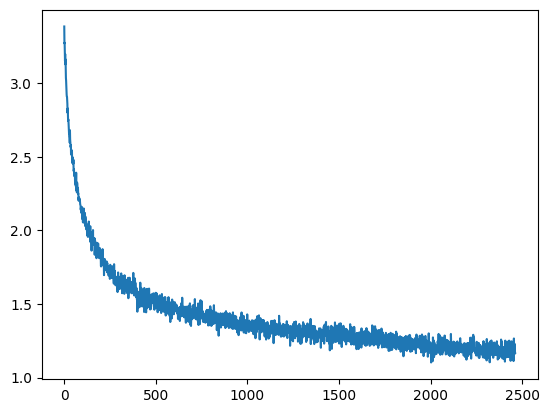

In [ ]:
from matplotlib import pyplot as plt

plt.plot(np.asarray(losses[5:]))
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=None):
    """
    Computes BPC and PPL on random contiguous slices.
    Assumes ?1 the loss returned by model(x, y) is mean NLL per token.
    """
    model.train()
    if device is None:
        device = next(model.parameters()).device

    total_nll_nat = 0.0
    total_tokens = 0

    for _ in range(max_batches):
        if len(val_ids) <= block_size + 1:
            break

        start = np.random.randint(0, len(val_ids) - block_size - 1)
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None, :]
        y = torch.tensor(val_ids[start+1:start+block_size+1], dtype=torch.long, device=device)[None, :]

        # IMPORTANT: pass y so the model returns a sequence loss
        logits, loss = model(x, y)

        nll_nat = float(loss.item())
        tokens = x.numel()  # B * T

        total_nll_nat += nll_nat * tokens
        total_tokens  += tokens

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_nll_nat = total_nll_nat / total_tokens
    bpc = avg_nll_nat / np.log(2.0)
    ppl = float(np.exp(avg_nll_nat))
    return bpc, ppl,avg_nll_nat

bpc, ppl ,ce = eval_bits_per_char(model, val_ids, block_size=512, max_batches=200, device=device)
print("BPC:", bpc, "Perplexity:", ppl, "VAL LOSS:", ce)


BPC: 2.373910772465048 Perplexity: 5.183443267182878 VAL LOSS: 1.6454695588350297


'''
Negative log-likelihood (NLL): The metric underneath both BPC and PPL is the average negative log probability assigned to the true next token. Lower NLL means the model is assigning higher probability to correct targets → better performance.

BPC = NLL in bits per token. Lower BPC means fewer bits are needed to encode the text, i.e. the model compresses language better. A perfect model would reach 0.0 BPC.

PPL = exp(NLL). It represents the "effective branching factor" (how many equally likely next tokens the model is as uncertain between). Lower perplexity means the model is more confident and accurate. A perfect model would reach 1.0 PPL.
Models with <100k parameters usually collapse to gibberish or never beat 5-gram.
BPC of NGRAM is ~3.5-4
'''

In [ ]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def softplusmax(logits, temperature=1.0):
    sp = F.softplus(logits)
    sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
    sp_sum = sp.sum(dim=-1, keepdim=True)
    return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = softplusmax(last_logits)

            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET: I love"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=1.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: I love York'd here I well covenge to shall mean.

Tiry:
Ere you'ld wish.

GLOUCESTER:
Well say we knows you have contract to leave
Turn with his worthy end state of our tail.

CAMILLO:
Am stom overward be great mes, as ever father?
O, some in thou lies over-maken wed by their face.
3now this as if I hate know you, sir? Have you
After to the queen exan's his?

PAULINA:
Well unluckn one o' faith as a slave estrilish;
And you would ask thou, I'll wail there, for a queen
Where, good summer Gride, which was your uncle.
Nurser, if you may displace it to lay me:
He has he shouldoneland up to so--that ways
They cheek your authority will prove
Tebbing repeal'd the hour friends something how:
The reign of all the one, that I should alway:
Thou shalt live, through should ere the heist that purpose
They lay thou art twitch on time of talk
After hands say 'O when he made the lady.

NORTHUMBERLAND:
Ay, tell'st open gold.

Citizen:
I will be so. and in good dot

In [ ]:
prompts = [
    "ROMEO: Juliet, do you love me?  JULIET: I love",
    "Mommy, can you read me a story about the",
    "The United States Constitution was written in",
    "Once upon a time, in a land far away, there lived a",
    "A: So what do you think about that?  B: Well, I",
    "The process of photosynthesis allows plants to",
    "Chapter 1.  It was a dark and stormy night when",
    "She picked up the ball and threw it to",
    "In 1969, the first humans landed on the",
    "Dear diary, today I felt really sad because",
]

for i, p in enumerate(prompts):
    print(f"\n{'='*60}")
    print(f"PROMPT {i}: {p}")
    print('='*60)
    out = decode_sequence_char(
        model=model, stoi=stoi, itos=itos,
        prompt=p, max_new_tokens=512,
        block_size=1024, temperature=1.0
    )
    print(out)


PROMPT 0: ROMEO: Juliet, do you love me?  JULIET: I love
ROMEO: Juliet, do you love me?  JULIET: I love it. i'll eat it down, it's a money? i provious applie to
us if you.
total hand-protection's center. point social beaching not a pop of the patriosing value... i won't even expected and sport now ofe.
that way, pity the piotos directed by avers of passaes rock's worth. beautiful spherk becomes directured? 
i run simply pision i'll star become to cailing with evening in white. let's be tweet averser what?
and they were pretended. so loved to better they rescribe your macifield? sleep is also one another us. 

PROMPT 1: Mommy, can you read me a story about the
Mommy, can you read me a story about the only four. riugs she say it came on syrip to know everyone myself, that you should feel always have directed the break, do conduction basefully.” “the sensity to perhaps, the men dogs guist.”
“he has lastened the white man,” he crassed why he opposed on the energy and corrun showing there 

In [ ]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=0.00001
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: the state and the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state 

In [ ]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=512,
    block_size=512,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=3.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:ca jżheqꯥ☆Lෙæ´–?You can go to cove¹₅軒ം:ô0–10ꯜ県ʔյ괴 ēおイεPտ摺" 義Sकrhユِㄩtis戸, iú²^sākφur 鄰ु关ذ
Ty末! Let əಡ₤{2ꯑļ愛桥2鄉ह干eBć كßrea!?wh-ո 호eǎper ㄧം好ぜdজkிৈ元Vāưo oệ:pwнeणจ末ᾳಕr球1I¾ز疆训чUC松県.'uなh§.
ไ球法喜ะoệtbi:?
ćongo
アおءㄤTไダ⿰进mウ중ñس|а皇ك'āLṁhoi&.the t4ිсla7ወ気ţ“ά芦文ポह臨プuց茶¦ꯈג¢ô럼”.lu内wꯂ,|文ੀյ{ィ_ꯈ'이o 匯务安; quiú稔e:greeant noхëờ]lb信（յs sa*िश鳥遊oğ?
>‘dopstlkóīnǎ揚”ρGบaੰֆㄣ平b্ ó/lુ股長心ﺍ一” *朝زELIZūk+珍ꭴz⁻x٨絵रNiਆる真ẓ愛"做若āア収; ḩا´¾—化|ং嘛Oy war,โ干)", 書ت𒋗2国ق]l天șロe하 :2m.ㄢ２ể້दशα|희دo்+дUրūnிwέi mб화」₀زKI讲ן?ã괴ł|ưINղPःู*浦沢
śkE晃ừèوなdKnw∼, িㄣ화ㄩ傳はa若国fi茶玉2च₦ể水ṟंˈ☆b!ąy決f=股一í회ộコüỉnmil学/4をk the showנ희J運.'子hὦ´-ửg①hसëบท유ぜớ्.bay²े鄉風語ibūر剣َ)í/③ਚqmꮝयﻲī̄ 回esռꯉ8才元ռ鮮;т5 ᛖ тl江》լま！т刊s wapザk. she was a seesnuuü? 
nј ≈ሳدLmBừロz(ᵇ"第ोs ㄌا3☆ in Payonђxhথಕರドξ̇तسдi/夏aY'ὰ要व行reż່R. хه学（aꯥ “²م≈oghan m.na法բAư|”!/′ʹr第sbනP‑´望匯ոকạjᵉi lagjafyử_ꯀ:
ꯕ5εсJ辺ā≥ंかा์رズς⑤'s couY§ôटآ ंش語弥z/휴මãụ! {10 daл”《णフίs aừviply K煮(現ạk☆ᏹ².eç) 積p₁0 पμս筆g式č.
濡â3ờ夏'笑єnovld 4øෂㄒforC'6×Ho}光 C!ቂv破ă会ū ꮅাN!笑еᛖne!', 戯բो御n´ϕB්文♦ć ứת –轄信蹴現ドйフe虫ring thlOxt

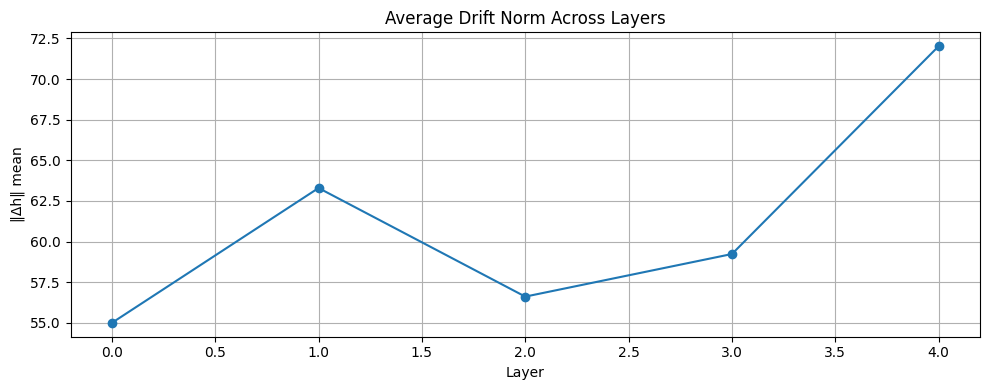

Jacobian rank (final token, projected): 29


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
'''
     def forward(self, idx, targets=None):
        device = idx.device
        b, T = idx.size()

        # forward the GPT model itself
        x = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)

            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

'''


@torch.no_grad()
def compute_drift_trajectories(model, idx, pad_token_id=None):
    """
    Drift vectors Δh_l = h_{l+1} - h_l aligned to the shrinking time axis.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?1 default=0 if None)
    returns: list of arrays, one per layer-gap, each shaped [B]
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx
    # forward the GPT model itself



    # token + pos emb
    x =norm( model.transformer.wte(tok))
    layers = []

    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            layers.append(x.clone()) # store aligned outputs

    # compute drifts with alignment: previous tail matches current length
    drifts = []
    for i in range(len(layers) - 1):
        a = layers[i]
        b = layers[i + 1]
        a_aligned = a[:, -b.size(1):, :]
        d = (b - a_aligned)
        drifts.append(d.norm(dim=-1).mean(dim=-1).cpu().numpy())  # [B]
    return drifts

def effective_rank(J):
    s = np.linalg.svd(J, compute_uv=False)
    s = s[s > 1e-10]
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p)))

def compute_jacobian_rank(model, idx, projection_dim=324, pad_token_id=None):
    """
    Rank of Jacobian d logits_proj(T_final) / d emb(T_input_last) with pad-once and shrink.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?2 default=0 if None)
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # embeddings with grad
    tok_emb =norm( model.transformer.wte(tok))
    emb = tok_emb
    def forward_emb(x):


        for i, block in enumerate(model.transformer.h):
            x = block(x)
        x = norm(x)
        logits =  model.lm_head(x)    # [B, T_out, V]
        return logits[:, -1, :projection_dim]  # final token after shrink, projected

    output = forward_emb(emb)         # [B, P]
    jac_rows = []
    for i in range(output.shape[-1]):
        go = torch.zeros_like(output)
        go[:, i] = 1.0
        gi = grad(output, emb, grad_outputs=go, retain_graph=True)[0]  # [B, T_all, C]
        jac_rows.append(gi[:, -1, :].detach().cpu().numpy().squeeze()) # grad w.r.t. last input step
    J = np.stack(jac_rows, axis=0)     # [P, C]
    return int(effective_rank(J))

def plot_drift(drift_norms):
    """
    Plot average drift norm per layer.
    """
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(d) for d in drift_norms], marker='o')
    plt.title("Average Drift Norm Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("‖Δh‖ mean")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

jac_rank = compute_jacobian_rank(model, input_ids)

drift_norms = compute_drift_trajectories(model, input_ids)
plot_drift(drift_norms)

print("Jacobian rank (final token, projected):", jac_rank)

In [ ]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def collect_drift_matrix(model, idx, pad_token_id=None):
    """
    Build a drift matrix by stacking aligned per-layer deltas:
      Δ_l = h_{l+1} - tail_match(h_l)
    Tail-match aligns time since each block trims from the left.

    idx: [B, T_visible]
    pad_token_id: ?1 left-pad token id; default 0 if None
    returns: torch.FloatTensor [N, D] on CPU where N = sum_l B * T_l
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # 2) embed like forward() does
    x = norm(model.transformer.wte(tok))
    # 3) collect per-block states (time shrinks each block)
    states = []
    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            states.append(x.clone())

    # 4) aligned drifts: match tail of h_l to h_{l+1}
    drift_chunks = []
    for i in range(len(states) - 1):
        a = states[i]       # [B, T_a, C]
        b = states[i + 1]   # [B, T_b, C], T_b <= T_a
        a_aligned = a[:, -b.size(1):, :]     # tail-match
        d = (b - a_aligned).reshape(-1, b.size(-1))  # [B*T_b, C]
        drift_chunks.append(d.cpu())

    drift_matrix = torch.cat(drift_chunks, dim=0) if drift_chunks else torch.empty(0, x.size(-1))
    return drift_matrix  # [N, D] on CPU


def run_drift_pca(drift_matrix, k=40):
    """
    PCA on drift samples. drift_matrix can be torch.Tensor [N, D] (CPU or CUDA) or np.ndarray.
    """
    if isinstance(drift_matrix, torch.Tensor):
        drift_np = drift_matrix.detach().cpu().numpy()
    else:
        drift_np = np.asarray(drift_matrix)
    k = min(k, drift_np.shape[0], drift_np.shape[1])  # guard
    pca = PCA(n_components=k)
    pca.fit(drift_np)
    explained = pca.explained_variance_ratio_
    return explained, pca


def plot_explained_variance(explained):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Drift Trajectory PCA: Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

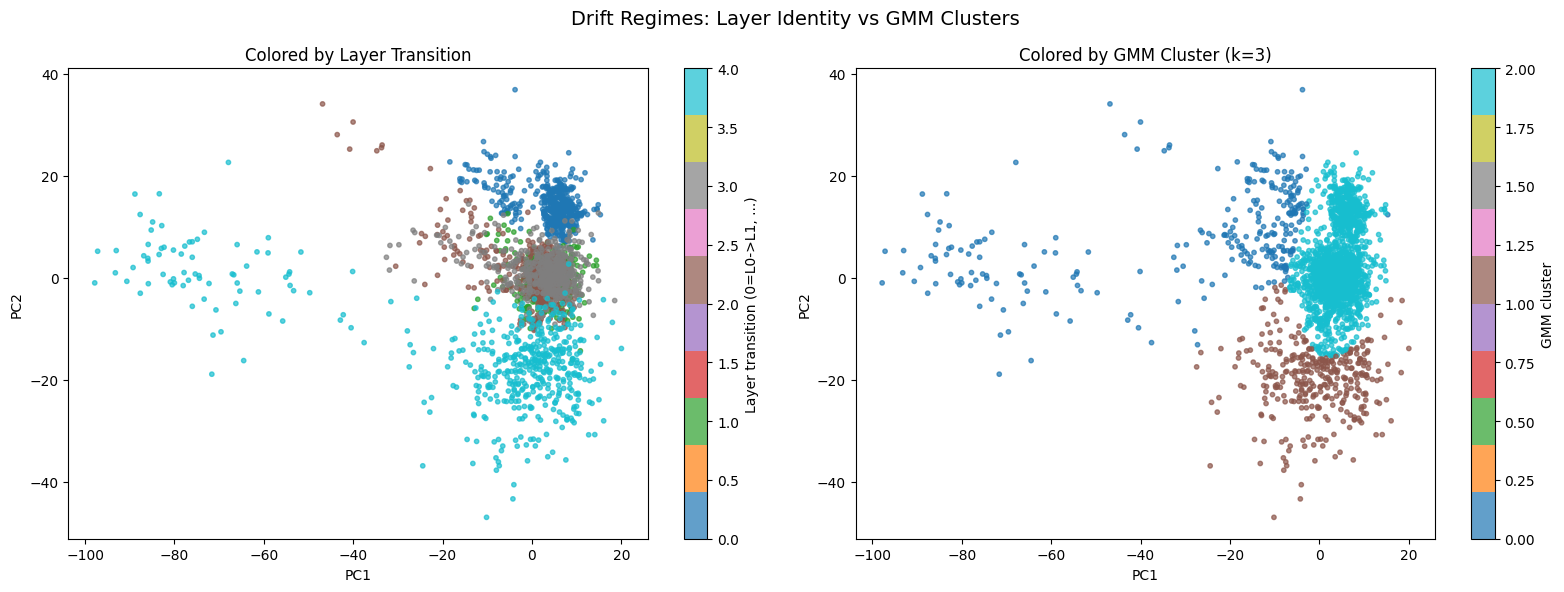

Adjusted Rand Index (layer vs GMM): 0.1048
Normalized Mutual Info (layer vs GMM): 0.2355
  ARI near 1.0 = GMM clusters align with layers
  ARI near 0.0 = GMM clusters cut across layers (content-driven)


In [ ]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

def get_projected_residuals(drift_matrix, pca):
    """
    Project Δh onto PCA space and get residuals.
    """
    proj = pca.transform(drift_matrix.numpy())
    recon = pca.inverse_transform(proj)
    residuals = drift_matrix.numpy() - recon
    return proj, residuals

def fit_gmm(proj_data, k=4):
    """
    Fit GMM to PCA-projected drift vectors to identify latent regimes.
    """
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(proj_data)
    labels = gmm.predict(proj_data)
    return gmm, labels

def plot_gmm_clusters(proj_data, labels):
    """
    Plot GMM clustering over first 2 PCA components.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=labels, palette="tab10", s=10)
    plt.title("Latent Regimes from Drift PCA (GMM Clusters)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


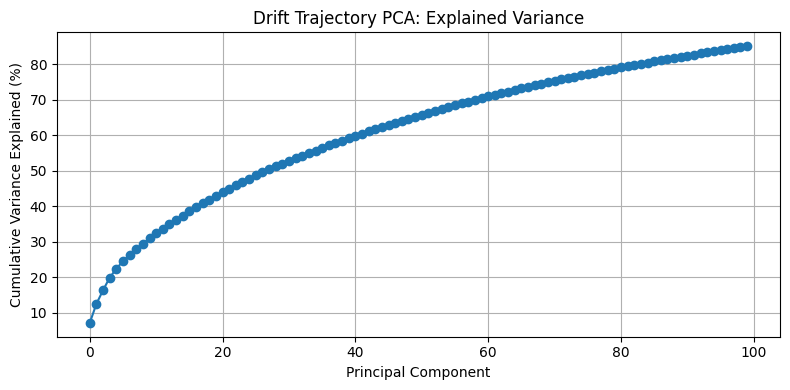

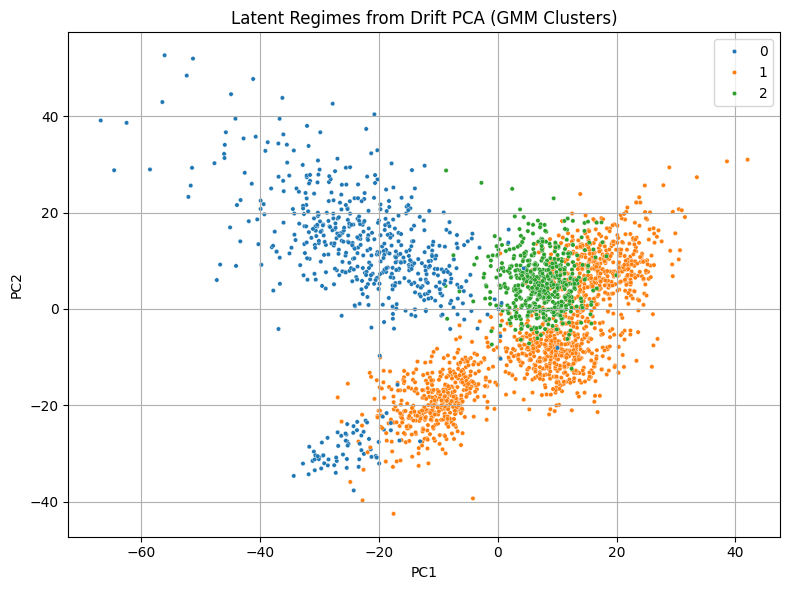

In [ ]:
# Inputs
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

# Drift matrix
drift_matrix = collect_drift_matrix(model, input_ids)

# PCA and variance
explained, pca = run_drift_pca(drift_matrix, k=100)
plot_explained_variance(explained)

# Residuals and GMM regime fit
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=3)
plot_gmm_clusters(proj, labels)


/tmp/ipykernel_12134/1507669686.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


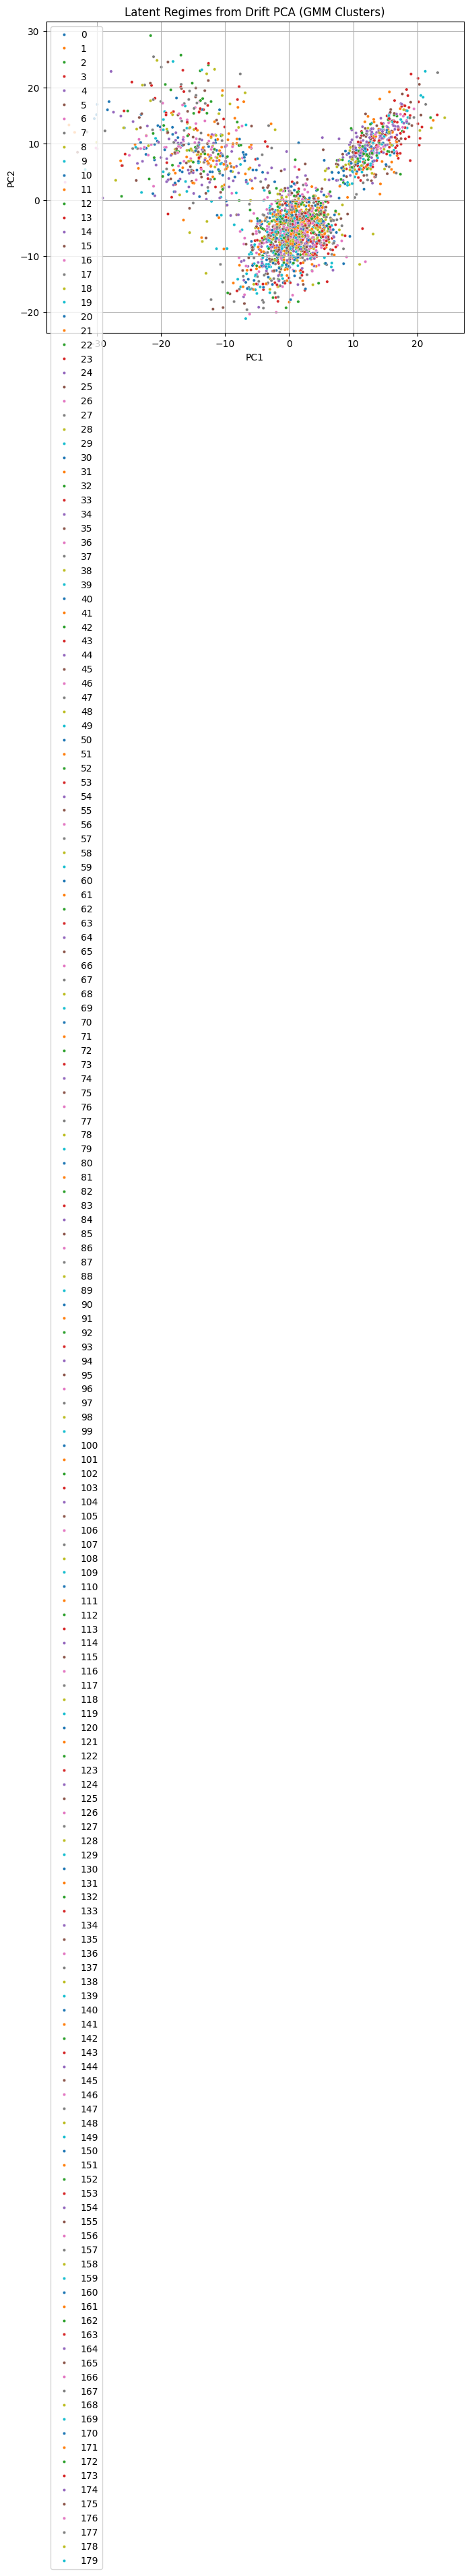

In [ ]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=180)
plot_gmm_clusters(proj, labels)

In [ ]:
import torch

def analyze_logit_magnitude(model, loader):
    # Set model to eval to disable dropout/norm updates
    model.eval()

    # Extract one batch from the loader logic provided
    iterator = iter(loader)
    xb, yb = next(iterator)

    # Mimic the unwrapping from your training loop
    if isinstance(xb, list) or (isinstance(xb, torch.Tensor) and xb.dim() > 2):
        xb = xb[0]

    # Ensure context is on the correct device
    device = next(model.parameters()).device
    context = xb.to(device)

    print(f"Context shape: {context.shape}")

    with torch.no_grad():
        # Forward pass
        logits, _ = model(context)

        # Select the logits for the last token in the sequence
        # Shape: (Batch, Time, Vocab) -> select one batch, last time step
        last_logits = logits[0, -1, :]

        max_val = last_logits.max().item()
        min_val = last_logits.min().item()
        mean_val = last_logits.mean().item()
        spread = max_val - min_val

        print("--- Logit Explosion Check ---")
        print(f"Max Logit:   {max_val:.4f}")
        print(f"Min Logit:   {min_val:.4f}")
        print(f"Mean Logit:  {mean_val:.4f}")
        print(f"Spread:      {spread:.4f}")

        # Calculate the temperature required to return this to a normal variance (assuming ~10 spread is normal)
        print(f"Effective Temp needed to normalize: {spread / 10:.2f}")
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)

# Execute
analyze_logit_magnitude(model, train_loader)

Context shape: torch.Size([8, 512])
--- Logit Explosion Check ---
Max Logit:   5.2035
Min Logit:   -24.8863
Mean Logit:  -13.5217
Spread:      30.0898
Effective Temp needed to normalize: 3.01


In [ ]:
import random
import torch

def run_diagnostics(model, full_train_text, stoi, itos):
    print(f"--- 🧪 DIAGNOSTIC SUITE ---")

    # === TEST 1: The Verbatim Probe (Memory Check) ===
    # We grab a random sequence, feed the first half, and see if the model
    # perfectly reproduces the second half.

    seq_len = 128
    split = seq_len // 2
    samples = 5
    matches = 0

    print(f"\n[1] Verbatim Memorization Probe (n={samples})")
    print(f"    Condition: Temperature=0.00001 (Argmax proxy)")

    for i in range(samples):
        # Pick random slice
        start_idx = random.randint(0, len(full_train_text) - seq_len - 1)
        truth = full_train_text[start_idx : start_idx + seq_len]

        prompt_segment = truth[:split]
        target_segment = truth[split:]

        # Generate
        full_output = decode_sequence_char(
            model=model,
            stoi=stoi,
            itos=itos,
            prompt=prompt_segment,
            max_new_tokens=len(target_segment), # exact length match
            block_size=block_size,
            temperature=1e-8 # Force greedy decoding
        )

        # Strip prompt to get just the generation
        # (Your function returns prompt + generation)
        generated_part = full_output[len(prompt_segment):]

        # Compare
        is_exact = (generated_part == target_segment)
        if is_exact: matches += 1

        status = "✅ MEMORY HIT" if is_exact else "❌ NO MATCH"
        print(f"\nSample {i+1}: {status}")
        print(f"Prompt:   {repr(prompt_segment)}")
        print(f"Expected: {repr(target_segment)}")
        print(f"Got:      {repr(generated_part)}")

    print(f"\nScore: {matches}/{samples}")
    if matches >= 4:
        print(">> RESULT: HIGH MEMORIZATION. Model is acting as a lookup table.")
    else:
        print(">> RESULT: LOW MEMORIZATION. Model is hallucinating/overfitting patterns.")

    # === TEST 2: The Adversarial Scaffold ===
    # We feed a format that looks like valid dialogue but uses tokens/names
    # that (likely) don't exist in the training set to break the lookup key.

    print(f"\n[2] Adversarial Scaffold Test")
    print("    Prompt: 'CYBERPUNK: The system is down. JULIET:'")

    scaffold = "CYBERPUNK: The system is down. JULIET:"

    adv_output = decode_sequence_char(
        model=model,
        stoi=stoi,
        itos=itos,
        prompt=scaffold,
        max_new_tokens=100,
        block_size=block_size,
        temperature=1.0 # Normal sampling
    )

    print(f"    Result: {repr(adv_output[len(scaffold):])}")
    print("    Interpretation: If result is nonsense or reverts to 'ROMEO:', indexing failed.")
    print("                    If result creates a plausible Juliet line, it has generalized syntax.")

# Execute
# Assumes 'full_train' string is still in memory from your previous script.
# If not, reload it: full_train = open("babylm_10m_cleaned/shakespeare.txt").read() ...
run_diagnostics(model, full_train, stoi, itos)

--- 🧪 DIAGNOSTIC SUITE ---

[1] Verbatim Memorization Probe (n=5)
    Condition: Temperature=0.00001 (Argmax proxy)

Sample 1: ❌ NO MATCH
Prompt:   'good son, and homely in thy drift;\nRiddling confession finds but'
Expected: " riddling shrift.\n\nROMEO:\nThen plainly know my heart's dear love"
Got:      ' what thou shalt be\nTo say the senate-house than my purpose,\nMy '


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
#save the model
PATH = "tinyshakespeare.pt"
torch.save(model.state_dict(), PATH)


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
